# Telecom Customer Churn Dataset— Internship Project

---

## Track
**Supervised Learning Algorithm**

The random forest track focuses on analysing many decision trees to improve predictive performance. 
Each tree looks at different random parts of the data and their results are combined by voting for classification or averaging for regression.

---

## Dataset

**Telecom customer churn**

- **Source:** Saiket Systems
  
- **Size:** 7,043 rows, 21 columns
  
- **Columns:** customerID, gender, SeniorCitizen, Partner, Dependents,
       tenure, PhoneService, MultipleLines, InternetService,
       OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
       StreamingTV, StreamingMovies, Contract, PaperlessBilling,
       PaymentMethod, MonthlyCharges, TotalCharges, Churn
  
- **Goal:** Predicting Customers that will churn using Random Forest modelling
---

##  Key Findings

- **<12 months Customers:** Critical danger zone
  
- **Feature Importance:** Tenure, Total charges and Monthly charges
  
- **Best Model:** Tuned Random Forest with 90% recall, 84% precision and 178 correctly predicted Churn customers.
  
- **Model Accuracy:** 80% accuracy
  
- **AUC:** 0.838
  
- **Conclusion:** The SARIMA model successfully captured the seasonal patterns in chocolate sales and produced reliable forecasts
---

## GitHub Repository

https://github.com/dinioluwa/Telecom-Customer-Churn

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# importing the needed libraries to analyse the dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score,classification_report, recall_score
from sklearn.model_selection import GridSearchCV

In [3]:
#reading-in the csv dataset
df = pd.read_csv('C:\\Users\\HP\\Downloads\\Telco_Customer_Churn_Dataset.csv')

In [ ]:
# dataset overview: rows,columns,data types,memory usage,basic statistics.

In [4]:
df.head()            # first 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()                 # last 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# rows & columns counmns count
df.shape

(7043, 21)

In [7]:
df.columns            # column names 

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.dtypes                 # data types

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.info()                     # overview of all columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isna()                 # checking for missing values

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isna().sum()                 # sum of missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.duplicated().sum()                        # checking for duplicate rows

0

In [13]:
df.describe()                           # mean, min, max, std for numbers

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
df['customerID']       #checking customer ID column

0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object

In [15]:
df.drop(columns=["customerID"], inplace=True)           # drop customer ID column

In [16]:
# Changing TotalCharges to a numeric dtype
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
df["TotalCharges"]         #checking TotalCharges column

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [18]:
df.isnull().sum()                     # sum of missing values

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

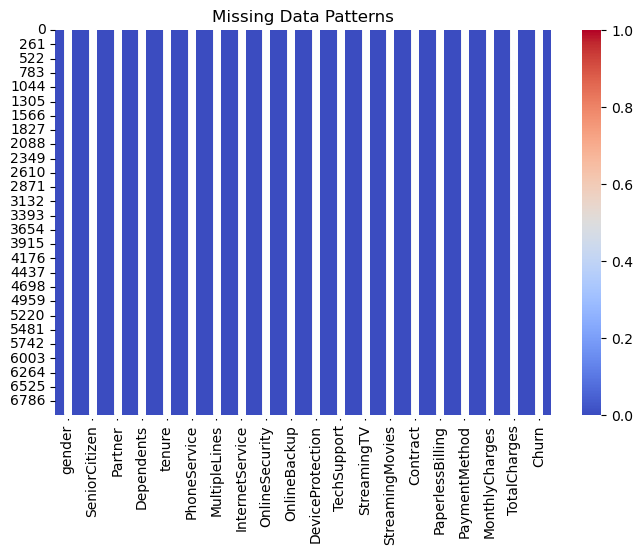

In [19]:
# heatmap for Missing Data Patterns

plt.figure(figsize = (8,5))
sns.heatmap(df.isnull() , cmap = 'coolwarm', annot=True)
plt.title('Missing Data Patterns')            
plt.show()

In [20]:
# new customers are charged nothing yet,filling with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)  

In [21]:
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [22]:
# Check duplicates
df.duplicated().sum()

22

In [23]:
#drop duplicates
df.drop_duplicates(inplace=True)

In [24]:
# Confirm
print(f"After removal: {df.duplicated().sum()}")
print(f"New shape: {df.shape}")

After removal: 0
New shape: (7021, 20)


In [25]:
# replacing no internet service and no phone service with No
df.replace("No internet service", "No", inplace=True)
df.replace("No phone service", "No", inplace=True)

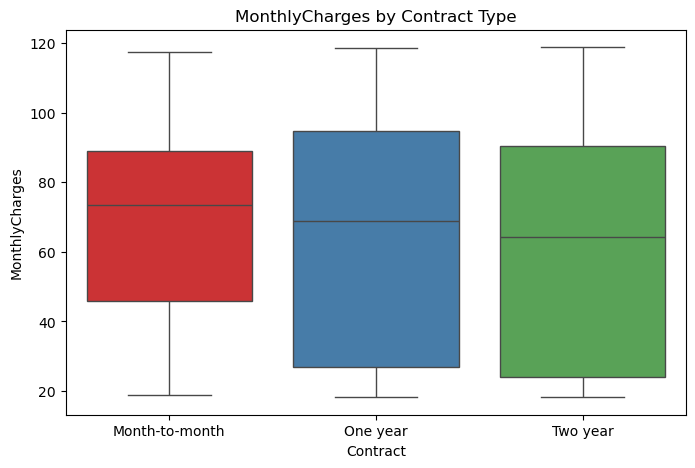

In [26]:
# MonthlyCharges vs Contract Type
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Contract", y="MonthlyCharges",
            palette="Set1")
plt.title("MonthlyCharges by Contract Type")
plt.show()

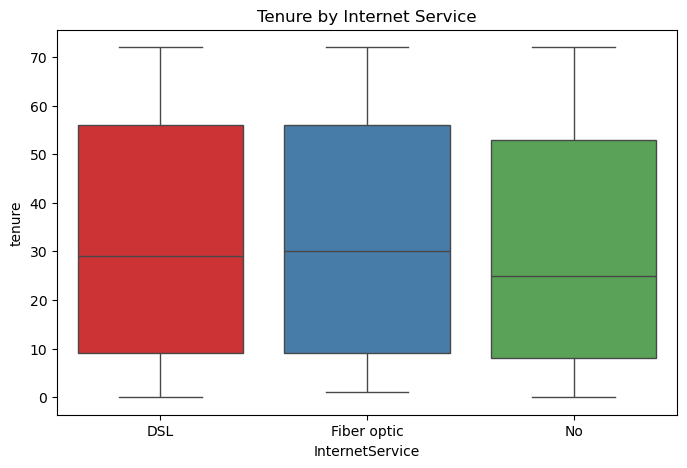

In [27]:
# Tenure vs InternetService
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="InternetService", y="tenure",
            palette="Set1")
plt.title("Tenure by Internet Service")
plt.show()

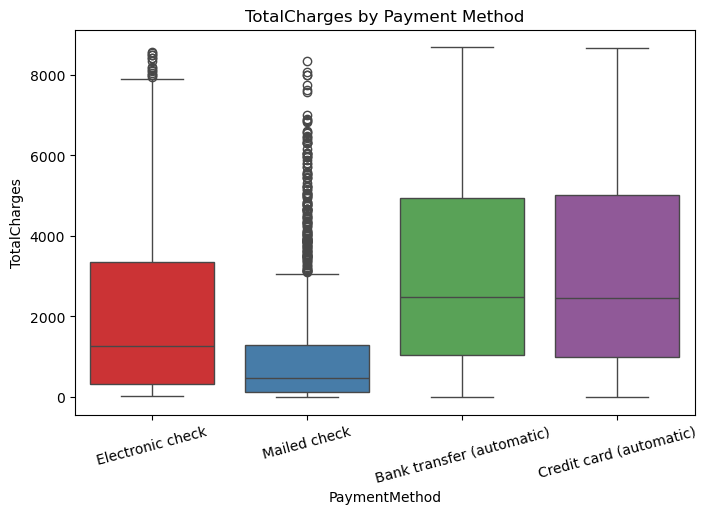

In [28]:
# TotalCharges vs PaymentMethod
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="PaymentMethod", y="TotalCharges",
            palette="Set1")
plt.title("TotalCharges by Payment Method")
plt.xticks(rotation=15)
plt.show()

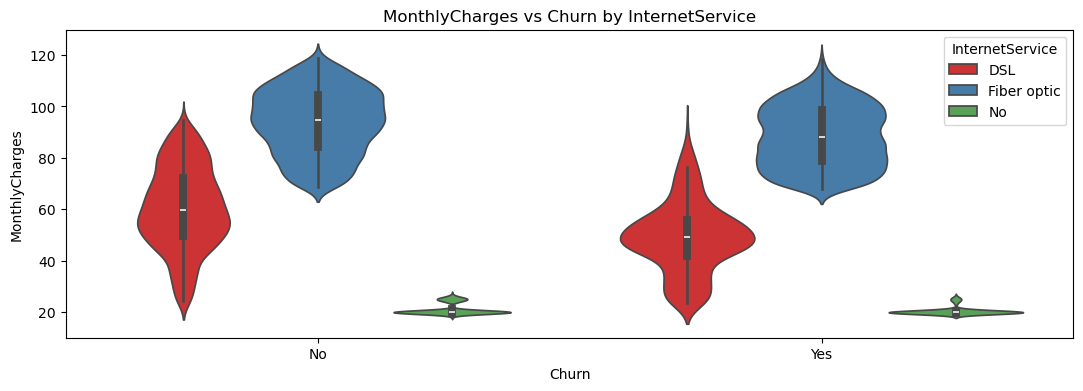

In [29]:
# MonthlyCharges vs Churn by InternetService
plt.figure(figsize=(13, 4))

sns.violinplot(data=df, x="Churn", y="MonthlyCharges", hue="InternetService", split=False,
              palette="Set1")
plt.title("MonthlyCharges vs Churn by InternetService")
plt.show()


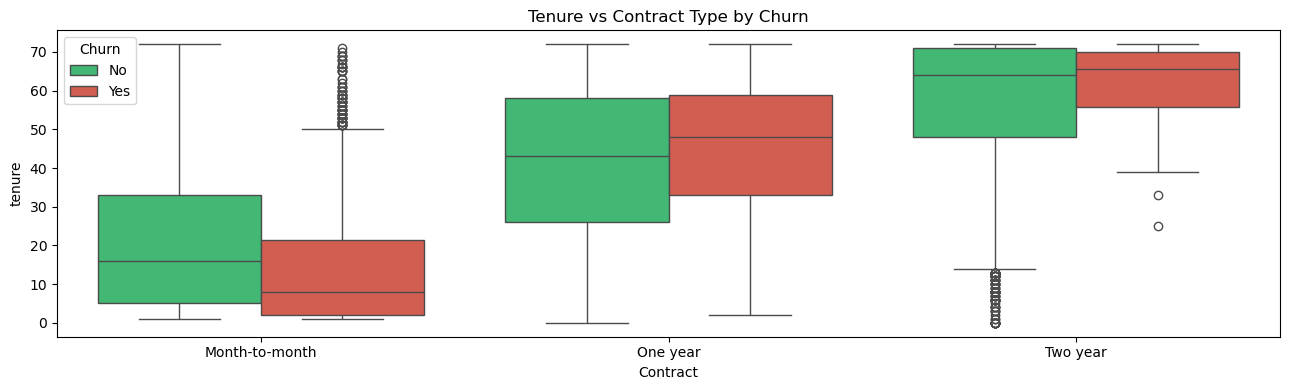

In [30]:
# Tenure vs Contract by churn
plt.figure(figsize=(13, 4))
sns.boxplot(data=df, x="Contract", y="tenure", hue="Churn",
         palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.title("Tenure vs Contract Type by Churn")
plt.tight_layout()
plt.show()

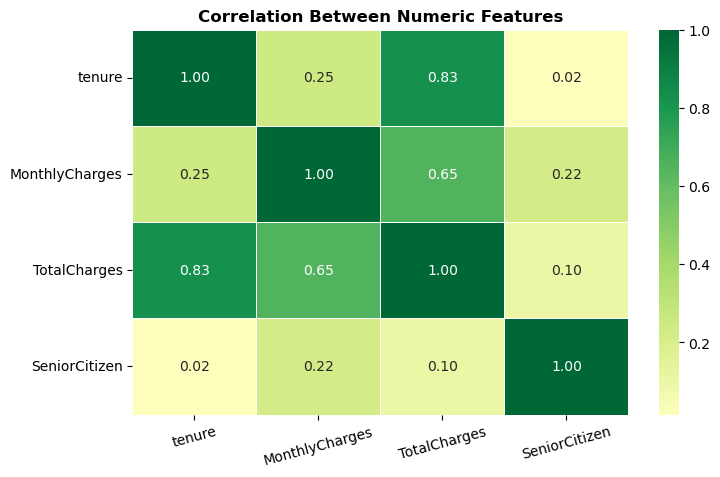

In [107]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 5))
numeric_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]]
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Numeric Features", fontweight="bold")
plt.xticks(rotation=15)
plt.show()

In [32]:
# churn value counts
Churn= df["Churn"].value_counts()

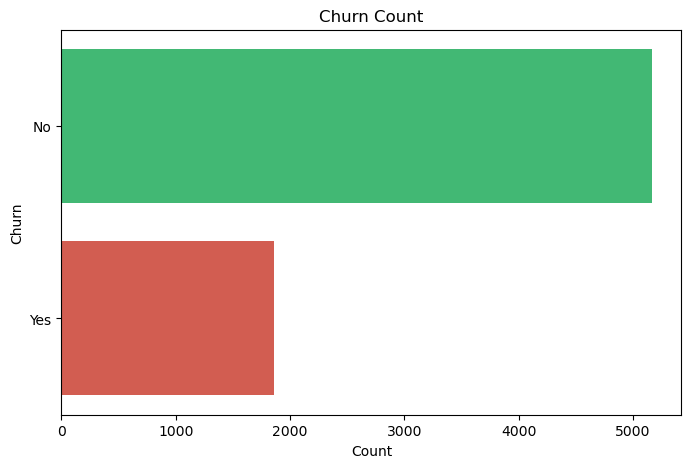

In [33]:
# Barplot showing customers that churn and customers that didn't churn
plt.figure(figsize=(8, 5))
sns.barplot(x=Churn.values, y=Churn.index, palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.title('Churn Count')
plt.xlabel('Count')
plt.ylabel('Churn')
plt.show()

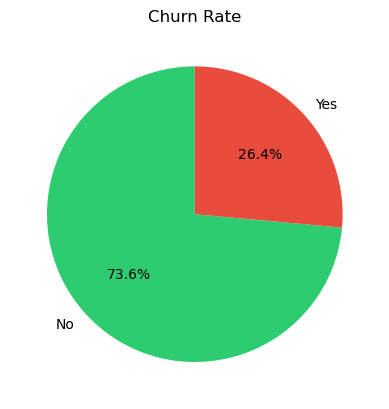

In [34]:
# piechart showing customers that churn and customers that didn't churn
plt.pie(df["Churn"].value_counts(), labels=["No", "Yes"], autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
plt.title("Churn Rate")
plt.show()

In [35]:
#gender value count
Gender = df['gender'].value_counts()
Gender

gender
Male      3541
Female    3480
Name: count, dtype: int64

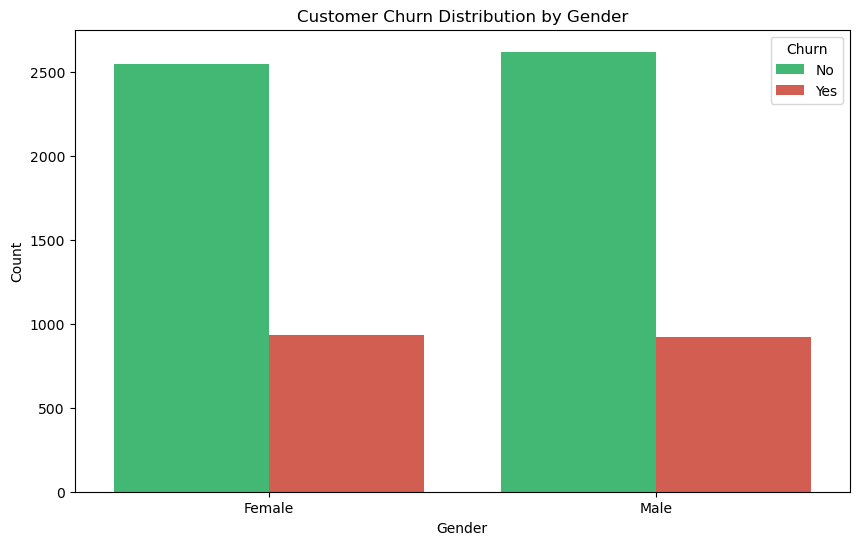

In [36]:
# Customer distribution by gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="gender", hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Customer Churn Distribution by Gender")
plt.show()

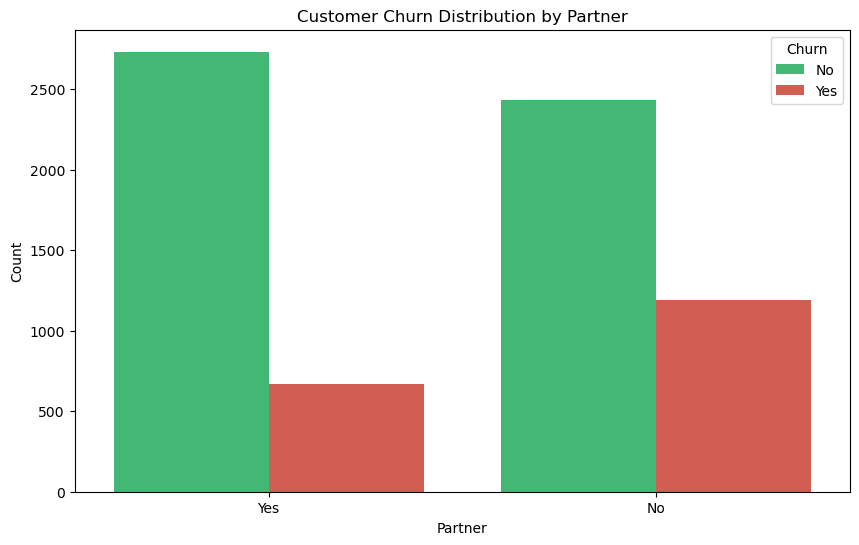

In [37]:
# Customer distribution by partner
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Partner", hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.xlabel("Partner")
plt.ylabel("Count")
plt.title("Customer Churn Distribution by Partner")
plt.show()

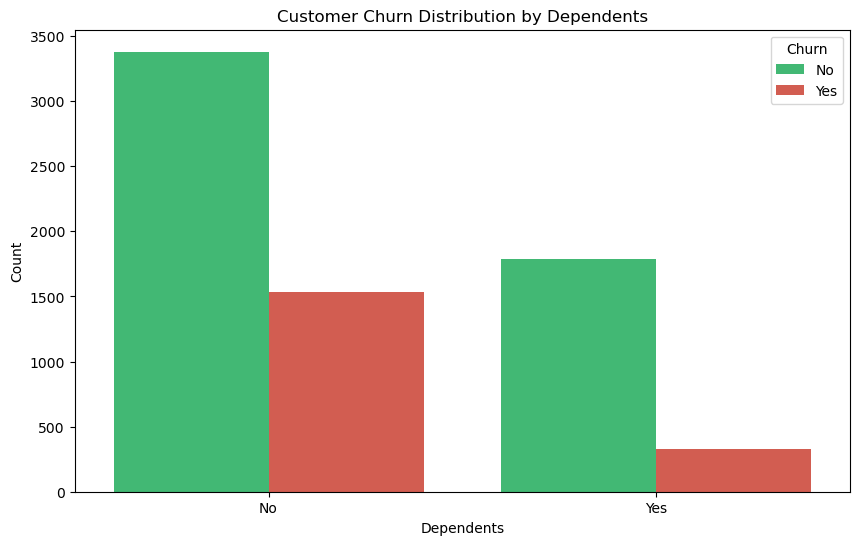

In [38]:
# Customer Churn Distribution by Dependents
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Dependents", hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.title("Customer Churn Distribution by Dependents")
plt.show()

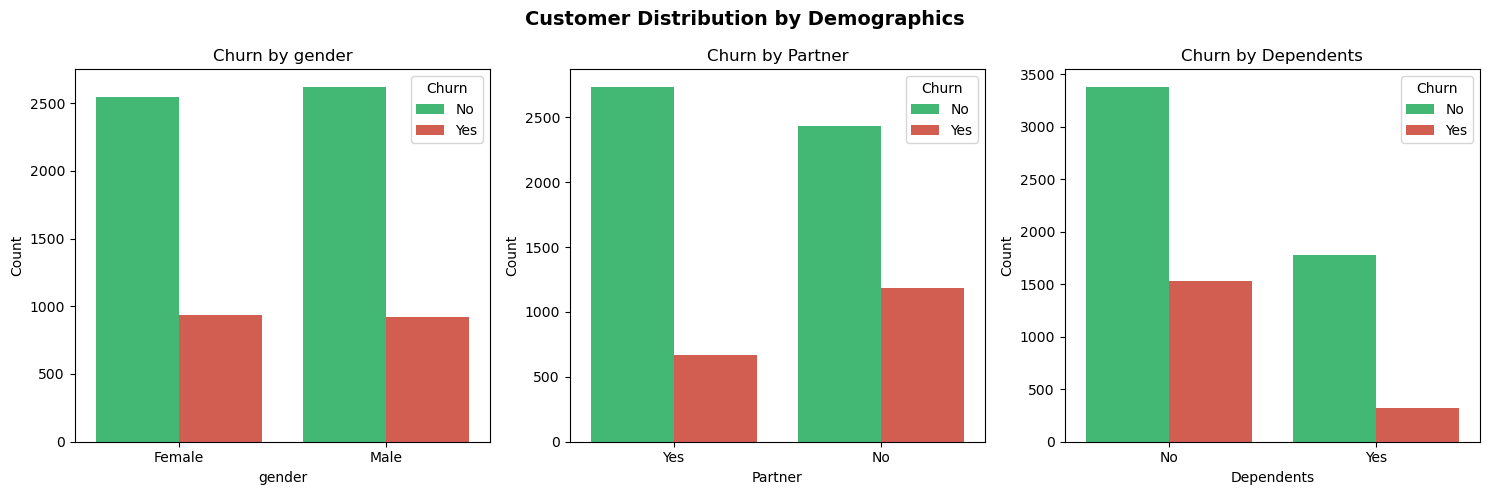

In [39]:
# Customer distribution by gender, partner, dependents
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ["gender", "Partner", "Dependents"]):
    sns.countplot(data=df, x=col, hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"}, ax=ax)
    ax.set_title(f"Churn by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(title="Churn")

plt.suptitle("Customer Distribution by Demographics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

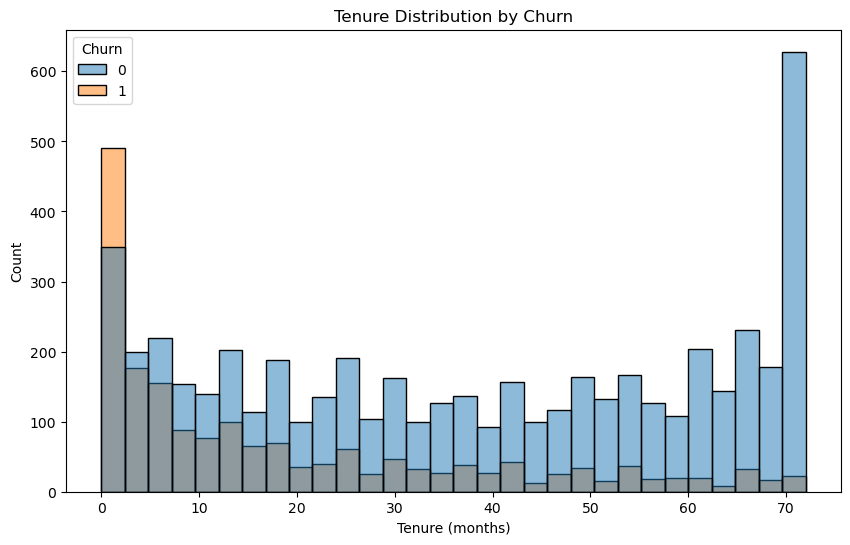

In [108]:
# Tenure Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Count")
plt.show()

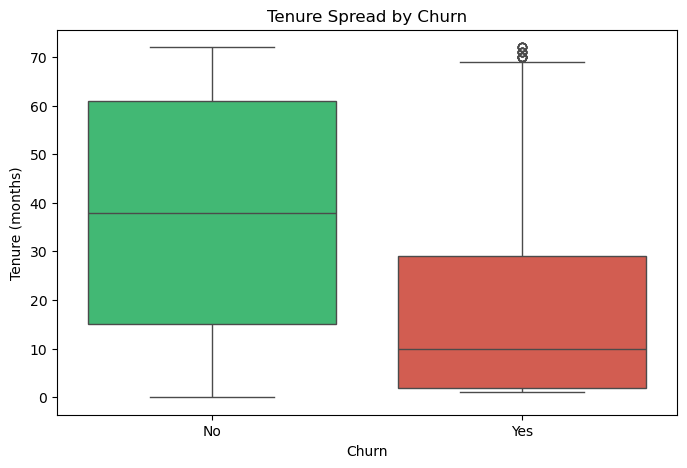

In [41]:
# Tenure vs Churn Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.title("Tenure Spread by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

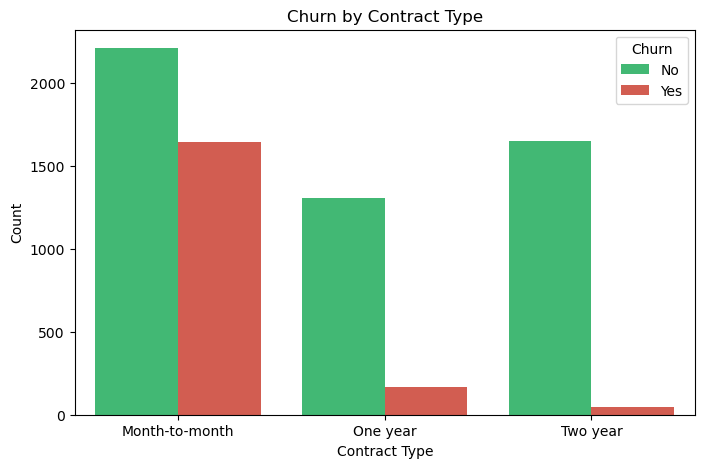

In [42]:
# Churn by Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

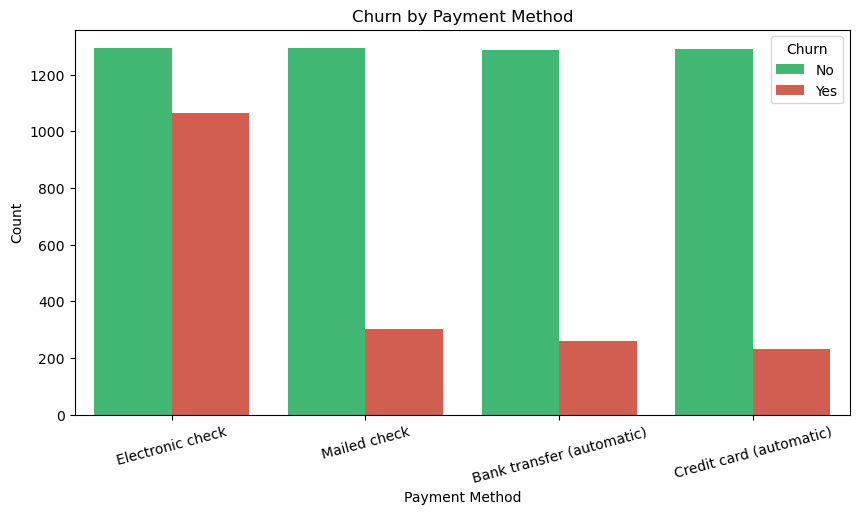

In [43]:
# Churn by Payment Method
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette={"No": "#2ecc71", "Yes": "#e74c3c"})
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

In [44]:
# Segmenting the tenure
df['Tenure_segment'] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72], 
                                   labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"])

In [45]:
# Checking Churn by Tenure
churn_by_tenure = df.groupby("Tenure_segment", observed=True)["Churn"].value_counts(normalize=True).unstack() * 100
churn_by_tenure

Churn,No,Yes
Tenure_segment,,
0-12 months,52.634011,47.365989
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


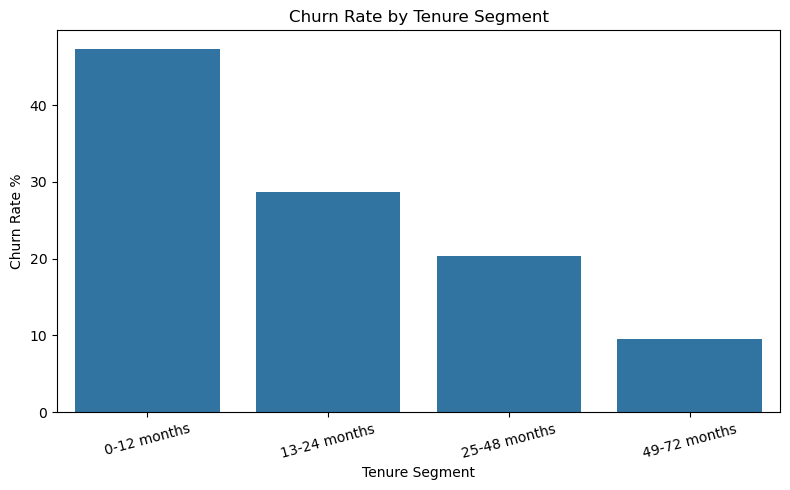

In [100]:
# Boxplot showing Tenure segment
plt.figure(figsize=(8, 5))
sns.barplot(x= churn_by_tenure.index,y=churn_by_tenure["Yes"])
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate %")
plt.title("Churn Rate by Tenure Segment")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

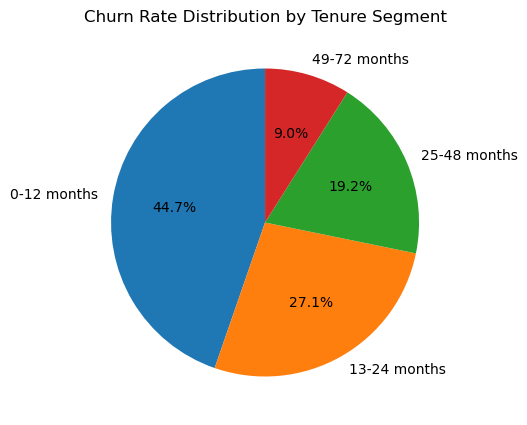

In [109]:
# Piechart showing the distribution of churn rate by tenure segment
plt.figure(figsize=(8, 5))
churn_by_tenure["Yes"].plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Churn Rate Distribution by Tenure Segment")
plt.ylabel("")
plt.show()

In [47]:
# # Segmenting the MonthlyCharges
df["Charge_segment"] = pd.cut(df["MonthlyCharges"], bins=[0, 35, 65, 95, 120],
                               labels=["Low (0-35)", "Medium (35-65)", 
                                      "High (65-95)", "Very High (95+)"])

In [48]:
# Checking Churn by Charge Segment
churn_by_charge = df.groupby("Charge_segment", observed=True)["Churn"].value_counts(normalize=True).unstack() * 100
churn_by_charge

Churn,No,Yes
Charge_segment,,
Low (0-35),89.250436,10.749564
Medium (35-65),76.972281,23.027719
High (65-95),64.203233,35.796767
Very High (95+),67.722008,32.277992


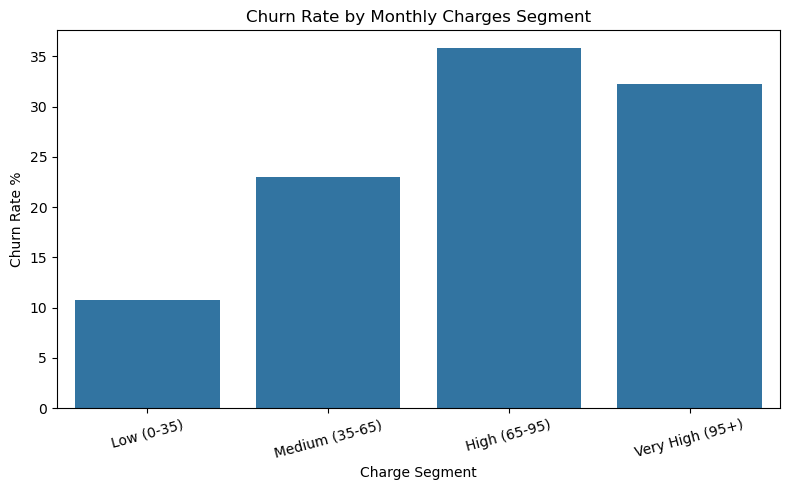

In [110]:
# Boxplot showing Charge segment
plt.figure(figsize=(8, 5))
sns.barplot(x= churn_by_charge.index,y=churn_by_charge["Yes"])
plt.xlabel("Charge Segment")
plt.ylabel("Churn Rate %")
plt.title("Churn Rate by Monthly Charges Segment")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

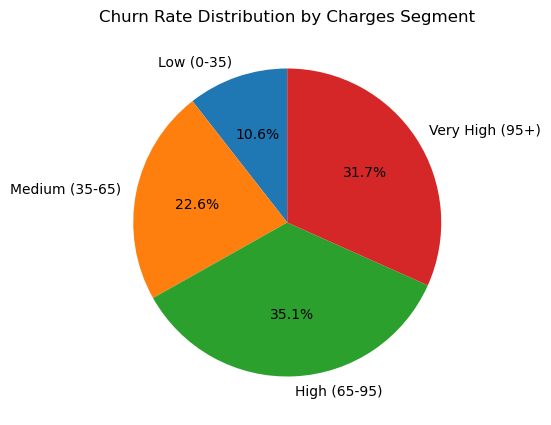

In [111]:
# Piechart showing the distribution of churn rate by charges segment
plt.figure(figsize=(8, 5))
churn_by_charge["Yes"].plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Churn Rate Distribution by Charges Segment")
plt.ylabel("")
plt.show()

In [50]:
# Checking Churn by Contract
churn_by_contract = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


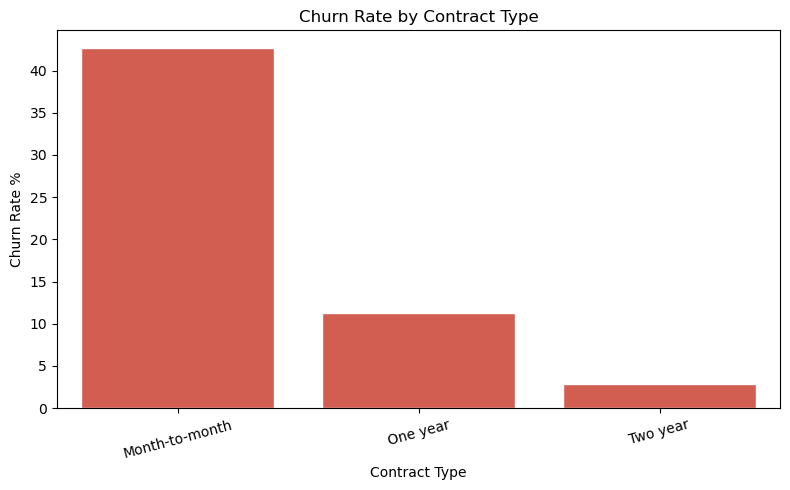

In [51]:
# Boxplot showing Contract segment
plt.figure(figsize=(8, 5))
sns.barplot(x= churn_by_contract.index,y=churn_by_contract["Yes"])
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate %")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

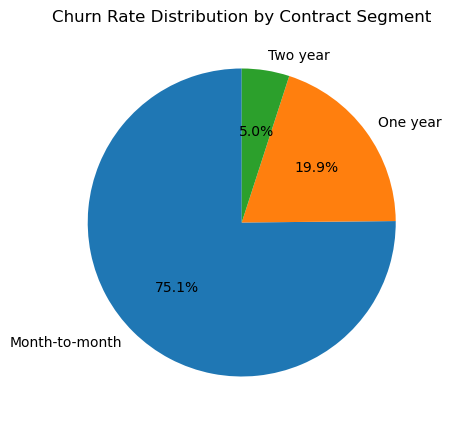

In [112]:
# Piechart showing the distribution of churn rate by contract segment
plt.figure(figsize=(8, 5))
churn_by_contract["Yes"].plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Churn Rate Distribution by Contract Segment")
plt.ylabel("")
plt.show()

In [52]:
# High-value-customers = high monthly charges + month-to-month contract + short tenure
high_value_at_risk = df[(df["MonthlyCharges"] > 65) &            # paying above average
    (df["Contract"] == "Month-to-month") &                      # no long term commitment
    (df["tenure"] <= 24) &                                     # early stage customer
    (df["Churn"] == "Yes")]                                   # already churned

In [53]:
# Showing high valued customers by tenure and monthly charges
high_value_at_risk[["tenure", "MonthlyCharges"]].head(10)

,tenure,MonthlyCharges
4,2,70.70
5,8,99.65
36,5,69.70
39,11,97.85
47,2,80.65
51,15,99.10
53,8,80.65
55,18,95.45
64,9,94.40
80,1,79.35


In [54]:
# Total number of high-value customers
print(f"Total high-value customers at risk: {len(high_value_at_risk)}")

Total high-value customers at risk: 872


In [55]:
# Binary columns 
binary_cols = [col for col in df.select_dtypes(include="object").columns
               if col != "Churn" and df[col].nunique() == 2]

In [56]:
# One-Hot Encode for Multi-class columns
multi_cols = [col for col in df.select_dtypes(include="object").columns
              if col != "Churn" and df[col].nunique() > 2]

In [57]:
# Showing binary and multi-class columns
print("Binary:", binary_cols)

print("Multi:", multi_cols)

Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Multi: ['InternetService', 'Contract', 'PaymentMethod']


In [58]:
# Initialize LabelEncoder
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [59]:
# Initialize Dummies
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [60]:
# Changing the churn column into integer
df["Churn"] = (df["Churn"] == "Yes").astype(int)

In [61]:
df.shape            # rows & columns counmns count

(7021, 26)

In [62]:
df.head()             # first 5 rows

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Churn,Tenure_segment,Charge_segment,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0,0-12 months,Low (0-35),False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,25-48 months,Medium (35-65),False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,0-12 months,Medium (35-65),False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,25-48 months,Medium (35-65),False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,0-12 months,High (65-95),True,False,False,False,False,True,False


In [63]:
# Converting the boolean columns to integer
df[df.select_dtypes(include="bool").columns] = df.select_dtypes(include="bool").astype(int)

In [64]:
df.head()                     # First 5 rows

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Churn,Tenure_segment,Charge_segment,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0,0-12 months,Low (0-35),0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,25-48 months,Medium (35-65),0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,0-12 months,Medium (35-65),0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,25-48 months,Medium (35-65),0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0-12 months,High (65-95),1,0,0,0,0,1,0


In [65]:
df.info()                       # overview of all columns

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   gender                                 7021 non-null   int32   
 1   SeniorCitizen                          7021 non-null   int64   
 2   Partner                                7021 non-null   int32   
 3   Dependents                             7021 non-null   int32   
 4   tenure                                 7021 non-null   int64   
 5   PhoneService                           7021 non-null   int32   
 6   MultipleLines                          7021 non-null   int32   
 7   OnlineSecurity                         7021 non-null   int32   
 8   OnlineBackup                           7021 non-null   int32   
 9   DeviceProtection                       7021 non-null   int32   
 10  TechSupport                            7021 non-null   int32   
 

In [66]:
# Drop missing values
df = df.dropna()

# Features and target
X = df[['gender','SeniorCitizen','Partner','Dependents','tenure','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup', 
        'DeviceProtection', 'TechSupport','StreamingTV','StreamingMovies', 
        'PaperlessBilling', 'MonthlyCharges','TotalCharges','InternetService_Fiber optic', 
        'InternetService_No','Contract_One year','Contract_Two year',
        'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check',
        'PaymentMethod_Mailed check']]

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
# Create and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier( max_depth=10, 
                                      min_samples_split=20, 
                                      min_samples_leaf=10, random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [68]:
# Make predictions for the tain dataset
dt_pred = dt_model.predict(X_test)

In [69]:
# Create a DataFrame for actual vs predicted values on the train set
results_df = pd.DataFrame({'Actual':y_test, 'Predicted': dt_pred})
display(results_df.head(10))

,Actual,Predicted
3918,1,0
2467,0,0
2885,0,0
3770,0,0
3753,0,1
4493,0,0
2178,0,0
2481,0,0
1569,0,0
1611,0,0


In [70]:
# Display some predictions
print("── Decision Tree ──")
print(classification_report(y_test, dt_pred, target_names=["No Churn", "Churn"]))
print(f"Accuracy:  {accuracy_score(y_test, dt_pred):.3f}")
print(f"Precision: {precision_score(y_test, dt_pred):.3f}")
print(f"Recall:    {recall_score(y_test, dt_pred):.3f}")
print(f"F1-Score:  {f1_score(y_test, dt_pred):.3f}")

── Decision Tree ──
              precision    recall  f1-score   support

    No Churn       0.83      0.86      0.85      1053
       Churn       0.54      0.48      0.51       352

    accuracy                           0.77      1405
   macro avg       0.69      0.67      0.68      1405
weighted avg       0.76      0.77      0.76      1405

Accuracy:  0.767
Precision: 0.538
Recall:    0.483
F1-Score:  0.509


In [71]:
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

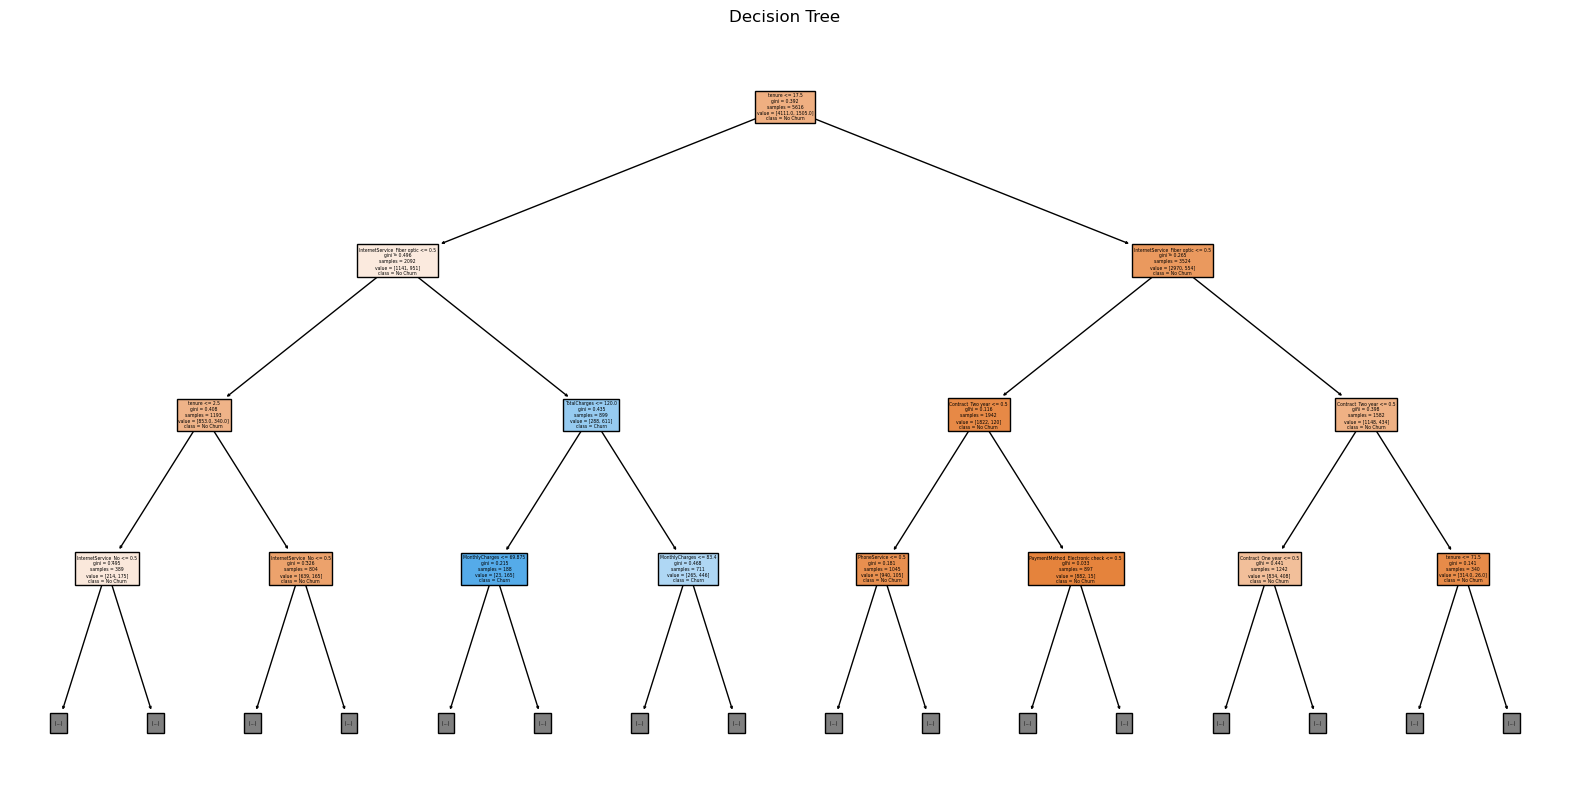

In [72]:
# Visualize a small portion of the tree (first few levels)
plt.figure(figsize=(20, 10))
tree.plot_tree(dt_model, feature_names=X_train.columns.tolist(), class_names=["No Churn", "Churn"],
          filled=True, max_depth=3)        
plt.title("Decision Tree")
plt.show()

In [73]:
# Create and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions for the test dataset
rf_pred = rf_model.predict(X_test)

In [74]:
# Evaluate Random Forest predictions

print("── Random Forest ──")
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.3f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.3f}")

── Random Forest ──
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1053
       Churn       0.59      0.46      0.52       352

    accuracy                           0.79      1405
   macro avg       0.71      0.68      0.69      1405
weighted avg       0.77      0.79      0.78      1405

Accuracy:  0.785
Precision: 0.591
Recall:    0.460
F1-Score:  0.518


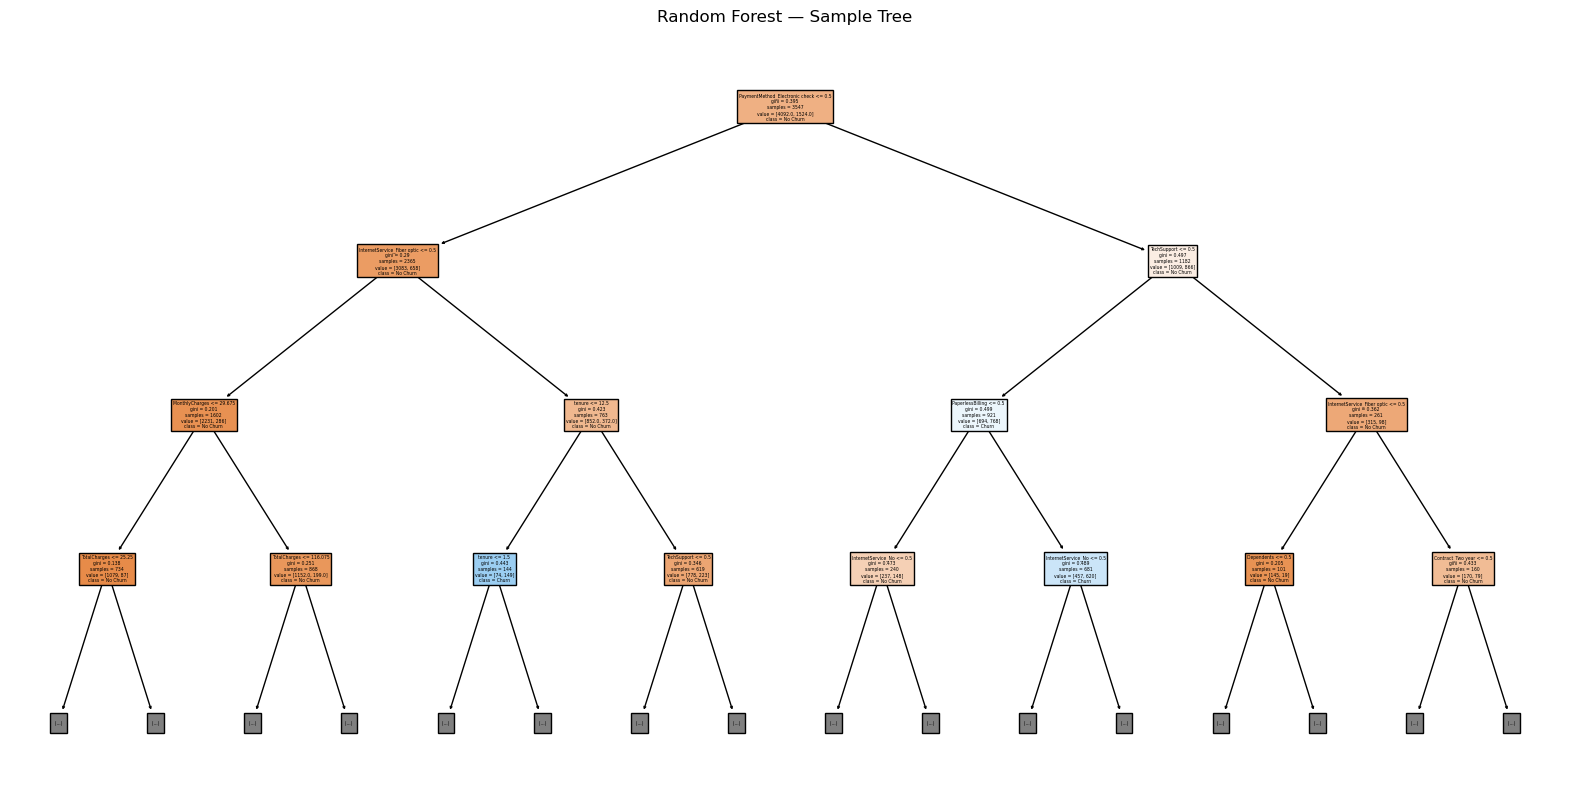

In [75]:
# Visualize a small portion of the tree (first few levels)
plt.figure(figsize=(20, 10))
tree.plot_tree(rf_model.estimators_[0], feature_names=X_train.columns.tolist(), class_names=["No Churn", "Churn"],
          filled=True, max_depth=3)   
plt.title("Random Forest — Sample Tree")
plt.show()

In [76]:
# Displaying Decision tree and Random Forest predictions
results = {"Decision Tree": {
        "Accuracy":  accuracy_score(y_test, dt_pred),
        "Precision": precision_score(y_test, dt_pred),
        "Recall":    recall_score(y_test, dt_pred),
        "F1-Score":  f1_score(y_test, dt_pred)},
    "Random Forest": {
        "Accuracy":  accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall":    recall_score(y_test, rf_pred),
        "F1-Score":  f1_score(y_test, rf_pred)}}

In [77]:
# Model Comparison
results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.round(3))



Model Comparison:
               Accuracy  Precision  Recall  F1-Score
Decision Tree     0.767      0.538   0.483     0.509
Random Forest     0.785      0.591   0.460     0.518


In [78]:
# Feature importance for Random Forest
feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)
print(feature_importance.head(10))

TotalCharges                      0.187417
MonthlyCharges                    0.176719
tenure                            0.170629
InternetService_Fiber optic       0.046525
PaymentMethod_Electronic check    0.039065
Contract_Two year                 0.033733
gender                            0.029315
PaperlessBilling                  0.027864
OnlineSecurity                    0.025447
TechSupport                       0.025348
dtype: float64


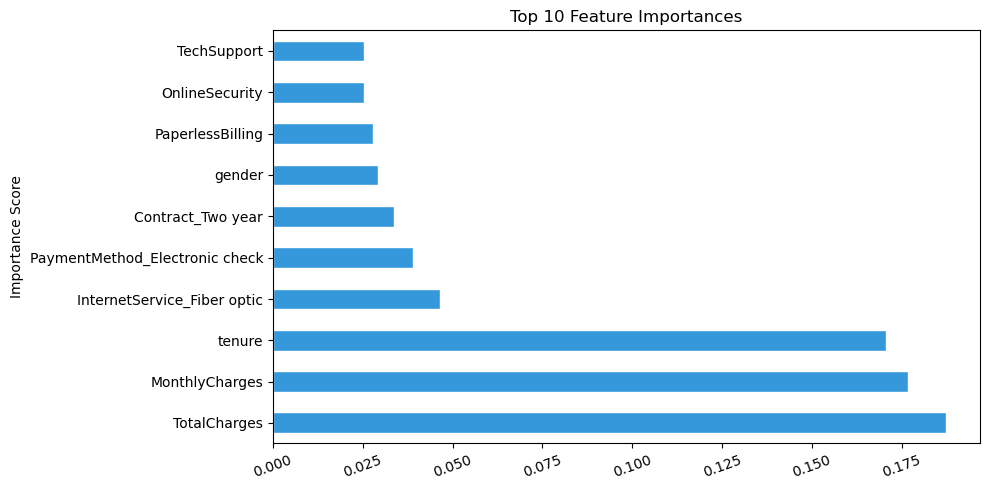

In [79]:
# Barplot showing Feature importance for Random Forest
plt.figure(figsize=(10, 5))
feature_importance.head(10).plot(kind="barh", color="#3498db", edgecolor="white")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [80]:
param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 5]}

In [81]:
grid_search = GridSearchCV( RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="f1",n_jobs=-1)

In [82]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [83]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:  ", round(grid_search.best_score_, 3))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score:   0.581


In [84]:
# Evaluate tuned model
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)

print("\n── Tuned Random Forest ──")
print(classification_report(y_test, best_pred, target_names=["No Churn", "Churn"]))


── Tuned Random Forest ──
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1053
       Churn       0.62      0.51      0.56       352

    accuracy                           0.80      1405
   macro avg       0.73      0.70      0.71      1405
weighted avg       0.79      0.80      0.79      1405



In [85]:
# Showing the best model predictions
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)
y_prob     = best_model.predict_proba(X_test)[:, 1]

print("── Best Model Evaluation ──")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

── Best Model Evaluation ──
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1053
       Churn       0.62      0.51      0.56       352

    accuracy                           0.80      1405
   macro avg       0.73      0.70      0.71      1405
weighted avg       0.79      0.80      0.79      1405



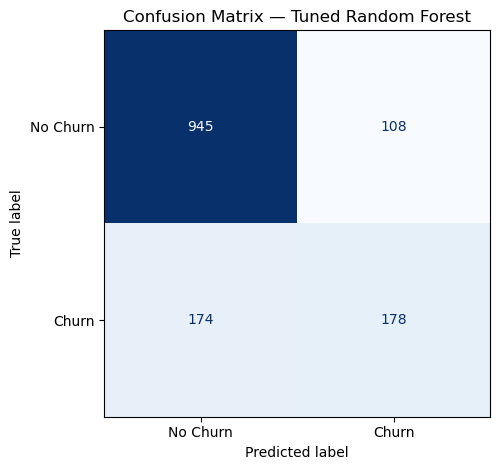


True Negatives  (correctly predicted No Churn): 945
False Positives (predicted Churn, actually No Churn): 108
False Negatives (predicted No Churn, actually Churn): 174
True Positives  (correctly predicted Churn): 178


In [86]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Churn", "Churn"])

disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout()
plt.show()

# Breakdown
TN, FP, FN, TP = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted No Churn): {TN}")
print(f"False Positives (predicted Churn, actually No Churn): {FP}")
print(f"False Negatives (predicted No Churn, actually Churn): {FN}")
print(f"True Positives  (correctly predicted Churn): {TP}")

In [87]:
# Feature importance for tuned random forest
feature_importance = pd.Series(best_model.feature_importances_,
                                index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

In [88]:
print(feature_importance.head(10).round(4))

tenure                            0.1979
TotalCharges                      0.1561
MonthlyCharges                    0.1359
InternetService_Fiber optic       0.0813
Contract_Two year                 0.0590
PaymentMethod_Electronic check    0.0583
Contract_One year                 0.0331
TechSupport                       0.0313
InternetService_No                0.0300
OnlineSecurity                    0.0285
dtype: float64


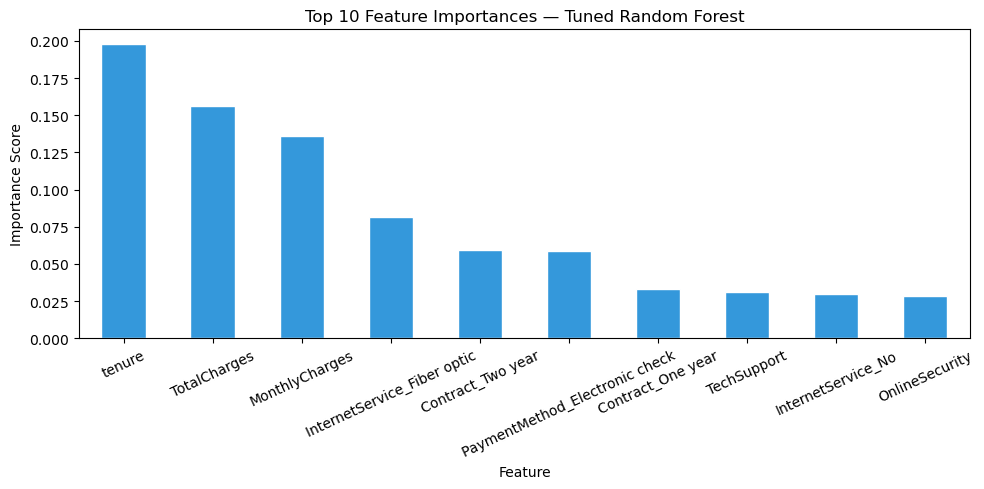

In [89]:
# Barplot showing feature importance of tuned random forest
plt.figure(figsize=(10, 5))
feature_importance.head(10).plot(kind="bar", color="#3498db", edgecolor="white")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

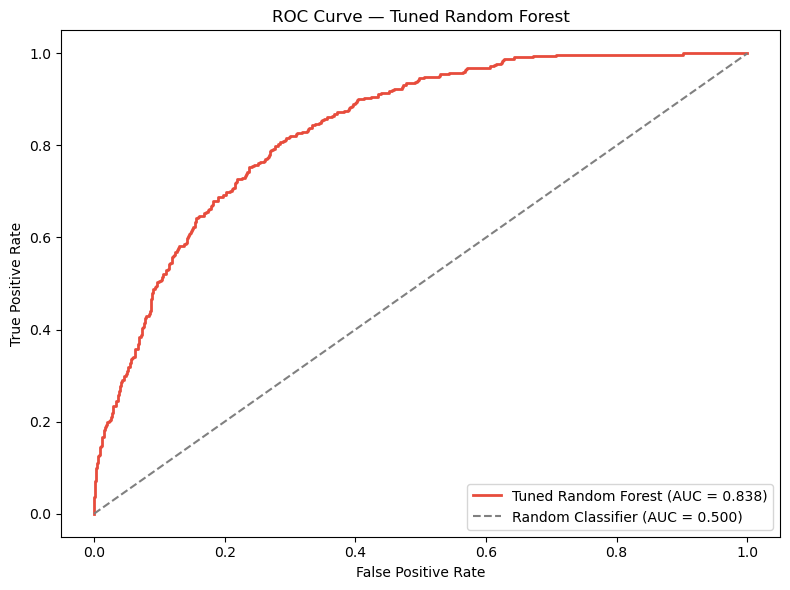


AUC Score: 0.838


In [90]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#e74c3c", lw=2,
         label=f"Tuned Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5,
         linestyle="--", label="Random Classifier (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"\nAUC Score: {roc_auc:.3f}")

In [91]:
print(f"\nAUC Score: {roc_auc:.3f}")


AUC Score: 0.838


# ***Recommendations***

***The Problem***
---
* Churn is highest in the first 12 months and customers who do not find value early leave fast.
* Month-to-month customers churn at 3x the rate of two-year contract customers.
* Fiber optic customers pay the most but churn the most
---

 ***Actions***

* Send automated check-in messages at Day 7, Day 30, and Day 90.
* Offer a free trial of one add-on service (OnlineSecurity or TechSupport) during the first 3 months to increase stickiness.
* Target specifically customers in the 0–12 month tenure window before they reach the decision point.
* Offer month-to-month customers a 10–15% discount to upgrade to a one or two-year contract.
* Conduct a customer satisfaction survey specifically for fiber optic customers also free speed upgrades or premium add-ons to justify the premium price.
* Integrate the model into the CRM system so it scores every customer monthly.
* Flag customers with churn probability > 60% for immediate outreach.
* Create a dedicated retention team that contacts high-risk customers with personalised offers.
* Track which interventions work and feed that data back to improve the model.

  ---
  
***Results***

* Revenue stabilises because long-term customers have higher lifetime value.
* Reducing early churn by even 10% would save approximately 350+ customers per year.
* Proactive intervention on the top 20% highest-risk customers can reduce overall churn by 5–8 percentage points.
  
  ---

# ***Action Plan***
---

**Immediate (0–30 days)**

* Deploy the churn model in the CRM

* Launch auto-pay incentive campaign

---
             
**Short Term (30–90 days)**

* Roll out the contract upgrade campaign

* Improve onboarding with automated check-ins

---
             
**Medium Term (90–180 days)**

* Launch fiber optic VIP program

* Create and promote service bundles

---

***NOTE***
---

* The model is currently catching 51% of churners. With more customer data, the recall can be improved to 65–70%, significantly increasing the impact of all these recommendations.